In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [2]:
# Load the dataset
df = pd.read_csv('train (1).csv')
print(" Dataset Sample:")
print(df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].head())

# Using consistent variable names (Uppercase X for features)
# Selecting the specific features requested
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']].values
y = df['SalePrice'].values

 Dataset Sample:
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1710             3         2     208500
1       1262             3         2     181500
2       1786             3         2     223500
3       1717             3         1     140000
4       2198             4         2     250000


In [3]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

print(" Multiple Regression model trained successfully.")

 Multiple Regression model trained successfully.


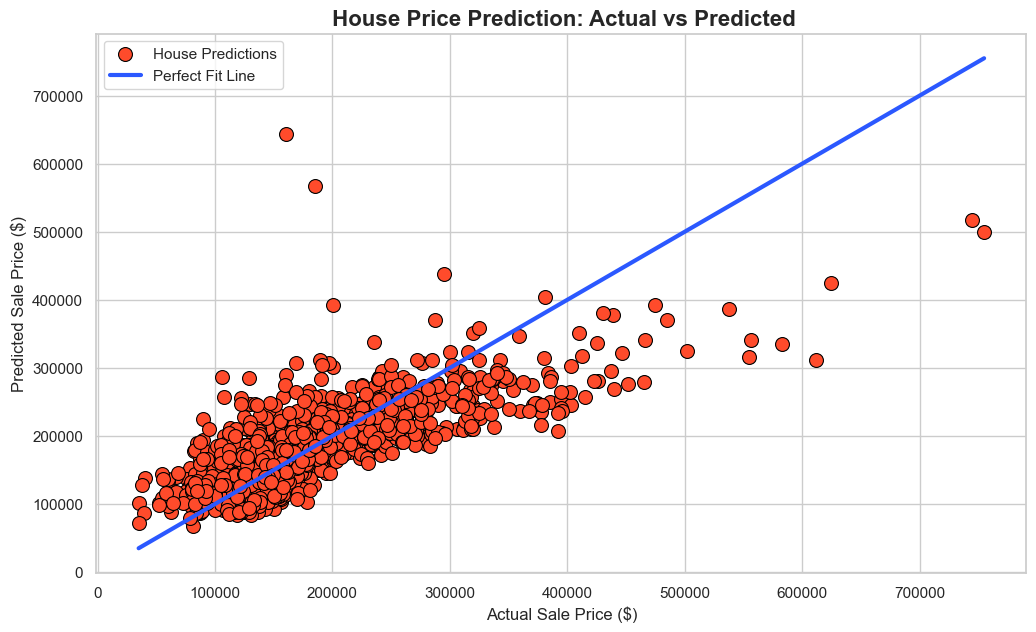

In [4]:
# Generate predictions for the training set
y_pred = model.predict(X)

# Visualize the accuracy
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y, y=y_pred, color='#ff4b2b', s=100, label='House Predictions', edgecolor='black')

# Plot the 'Perfect Prediction' line
max_val = max(y.max(), y_pred.max())
min_val = min(y.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='#2b58ff', linewidth=3, label='Perfect Fit Line')

plt.title(' House Price Prediction: Actual vs Predicted', fontsize=16, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.show()

In [5]:
# Model Evaluation
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Overall R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

Overall R² Score: 0.5832
Mean Squared Error: 2628535155.62


In [ ]:
# Custom Prediction Function with User Input
def predict_house_price(area, bedrooms, bathrooms):
    features = np.array([[area, bedrooms, bathrooms]])
    prediction = model.predict(features)[0]
    
    print(f"\n Prediction for {area} sqft, {bedrooms} Bed, {bathrooms} Bath:")
    print(f"Estimated House Price: ${prediction:,.2f}")

# Input from User
try:
    user_area = float(input("Enter Living Area (sq ft): "))
    user_beds = float(input("Enter Number of Bedrooms: "))
    user_baths = float(input("Enter Number of Bathrooms: "))
    
    predict_house_price(user_area, user_beds, user_baths)
except ValueError:
    print("Invalid input! Please enter numeric values for house features.")